In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install segmentation_models_pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.5 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import time
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [ ]:
def encoded_pixels_to_masks(fname: str, df: pd.DataFrame):
    fname_df = df[df['ImageId'] == fname]
    masks = np.zeros((256 * 1600, 4), dtype=np.float32)

    for i_row, row in fname_df.iterrows():
        cls_id = row['ClassId']
        encoded_pixels = row['EncodedPixels']
        if encoded_pixels is not np.nan:
            pixel_list = list(map(int, encoded_pixels.split(' ')))
            for i in range(0, len(pixel_list), 2):
                start_pixel = pixel_list[i] - 1
                num_pixel = pixel_list[i+1]
                masks[start_pixel:(start_pixel+num_pixel), cls_id-1] = 1

    masks = masks.reshape(256, 1600, 4, order='F') # запись из одномерного 256 * 1600 в двумерный (256, 1600) по столбцам

    return masks

### Sample example

In [ ]:
train_val_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train.csv'
test_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/sample_submission.csv'
train_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train_images/'
test_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/test_images/'

df = pd.read_csv(train_val_csv)

df.ImageId

,ImageId
0,0002cc93b.jpg
1,0007a71bf.jpg
2,000a4bcdd.jpg
3,000f6bf48.jpg
4,0014fce06.jpg
...,...
7090,ffcf72ecf.jpg
7091,fff02e9c5.jpg
7092,fffe98443.jpg
7093,ffff4eaa8.jpg


In [ ]:
# let's look at encoded pixels for the first image
img_id = '0002cc93b.jpg'
df[df.ImageId==img_id]

,ImageId,ClassId,EncodedPixels
0,0002cc93b.jpg,1,29102 12 29346 24 29602 24 29858 24 30114 24 3...


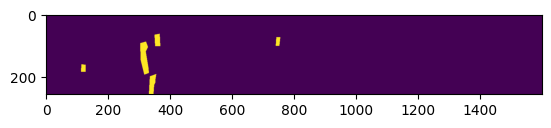

In [ ]:
masks = encoded_pixels_to_masks(img_id, df, )
plt.imshow(masks[:,:,0]*255)

In [ ]:
img = Image.open(os.path.join(train_folder,img_id))

In [ ]:
np.array(img).shape

(256, 1600, 3)

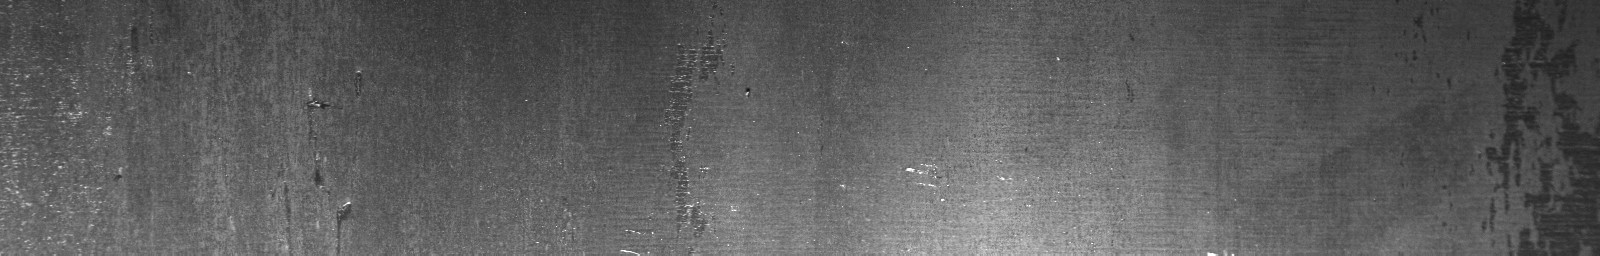

In [ ]:
img

In [ ]:
# let's encode masks back to encoded pixels
np.array(masks_to_encoded_pixels(masks)[0])

array([ 29102,     12,  29346,     24,  29602,     24,  29858,     24,
        30114,     24,  30370,     24,  30626,     24,  30882,     24,
        31139,     23,  31395,     23,  31651,     23,  31907,     23,
        32163,     23,  32419,     23,  32675,     23,  77918,     27,
        78174,     55,  78429,     60,  78685,     64,  78941,     68,
        79197,     72,  79452,     77,  79708,     81,  79964,     85,
        80220,     89,  80475,     94,  80731,     98,  80987,    102,
        81242,    105,  81498,    105,  81754,    104,  82010,    104,
        82265,    105,  82521,     31,  82556,     69,  82779,     27,
        82818,     63,  83038,     22,  83080,     57,  83297,     17,
        83342,     50,  83555,     13,  83604,     44,  83814,      8,
        83866,     37,  84073,      3,  84128,     31,  84390,     25,
        84652,     18,  84918,      8,  85239,     10,  85476,     29,
        85714,     47,  85960,     57,  86216,     57,  86471,     58,
      

In [ ]:
train_val_df = pd.read_csv(train_val_csv)
class_counts = train_val_df['ClassId'].value_counts().sort_index()

print(class_counts)
print(f"\nКоличество уникальных изображений: {len(train_val_df['ImageId'].unique())}")

ClassId
1     897
2     247
3    5150
4     801
Name: count, dtype: int64

Количество уникальных изображений: 6666


In [ ]:
total_samples = class_counts.sum()
num_classes = 4

class_weights = total_samples / (num_classes * class_counts)
class_weights = class_weights / class_weights.sum()
class_weights = class_weights.tolist()

print("Веса для классов:")
print(class_weights)

Веса для классов:
[0.16875917091999135, 0.6128622522883895, 0.029393587634025678, 0.1889849891575933]


### Your code starts from here

In [ ]:
class SeverstalSteelDataset(Dataset):
    def __init__(self, fnames, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.fnames = fnames

    def __len__(self):
        return len(self.fnames)

    def __getitem__(self, idx):
        img_id = self.fnames[idx]
        img_path = os.path.join(self.img_dir, img_id)
        img = np.array(Image.open(img_path).convert('RGB'))
        masks = encoded_pixels_to_masks(img_id, self.df)
        img = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1) # преобразуем в формат pytorch (channels, h, w)
        masks = torch.tensor(masks, dtype=torch.float32).permute(2, 0, 1)
        return img_id, img, masks

def collate_fn(batch_items):
    batched_fnames = [sample[0] for sample in batch_items]
    batched_imgs = torch.stack([sample[1] for sample in batch_items]).to(device)
    batched_masks = torch.stack([sample[2] for sample in batch_items]).to(device)
    return batched_fnames, batched_imgs, batched_masks


In [ ]:
class SegModel(torch.nn.Module):
    def __init__(self):
        super(SegModel, self).__init__()
        self.model = smp.Unet(encoder_name='resnet34', encoder_weights='imagenet', classes=4)

    def forward(self, x):
        return self.model(x)

In [ ]:
def load_data(train_val_csv, test_csv, train_val_img_dir, test_img_dir, max_samples=None):
    train_val_df = pd.read_csv(train_val_csv)
    train_val_fnames = pd.unique(train_val_df.ImageId)
    test_df = pd.read_csv(test_csv)
    test_fnames = pd.unique(test_df.ImageId)

    train_fnames, val_fnames = train_test_split(train_val_fnames, test_size=0.2, random_state=42)
    if max_samples:
        train_fnames = train_fnames[:max_samples]
        val_fnames = val_fnames[:max_samples]
        test_fnames = test_fnames[:max_samples]
    train_dataset = SeverstalSteelDataset(train_fnames, train_val_df, train_val_img_dir)
    val_dataset = SeverstalSteelDataset(val_fnames, train_val_df, train_val_img_dir)
    test_dataset = SeverstalSteelDataset(test_fnames, test_df, test_img_dir)

    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, collate_fn=collate_fn)#, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, collate_fn=collate_fn)#, num_workers=2)

    return train_loader, val_loader, test_loader

In [ ]:
class SeverstalSteelLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, class_weights=[1.0, 1.0, 1.0, 1.0], smooth=1e-6):
        super(SeverstalSteelLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth
        self.class_weights = class_weights

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(mode='multilabel', smooth=smooth, from_logits=True)

    def forward(self, predictions, targets):
        # (batch, 4, h, w)
        total_loss = 0.0

        for class_idx in range(4):
            pred_class = predictions[:, class_idx:class_idx+1]  # (batch, 1, h, w)
            target_class = targets[:, class_idx:class_idx+1]    # (batch, 1, h, w)

            bce_loss = self.bce_loss(pred_class, target_class)
            dice_loss = self.dice_loss(pred_class, target_class)

            class_loss = (self.bce_weight * bce_loss +
                         self.dice_weight * dice_loss) * self.class_weights[class_idx]

            total_loss += class_loss

        return total_loss

def init_model():
    model = SegModel().to(device)
    criterion = SeverstalSteelLoss(bce_weight=0.5, dice_weight=0.5, class_weights=[0.2, 0.5, 0.1, 0.2])  # бОльший вес для редких классов
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    return model, criterion, optimizer

def dice_score(pred, mask, smooth=1e-6):
    # (num_samples_in_batch, classes, h, w)
    pred_flat = pred.reshape(pred.shape[0], pred.shape[1], -1)
    mask_flat = mask.reshape(mask.shape[0], mask.shape[1], -1)

    intersection = (pred_flat * mask_flat).sum(dim=2) # суммирование по пикселям
    union = pred_flat.sum(dim=2) + mask_flat.sum(dim=2)

    dice = (2. * intersection + smooth) / (union + smooth)
    return dice.mean(dim=0) # усреднение по всем samples, по всему батчу для каждого класса

def evaluate(model, data_loader):
    model.eval()
    class_dice_scores = [[] for _ in range(4)]
    total_count = 0
    total_sum = 0.0

    with torch.no_grad():
      for filenames, images, masks in data_loader:
            #images, masks = images.to(device), masks.to(device)

            pred = (torch.sigmoid(model(images)) > 0.6).float() # порог для получения масок
            #pred = pred.cpu().numpy()
            #masks = masks.cpu().numpy()

            dice_per_class = dice_score(pred, masks)

            for class_i in range(4):
                class_dice_scores[class_i].append(dice_per_class[class_i].item())

    class_avg_dices = [np.mean(scores) for scores in class_dice_scores]
    avg_dice = np.mean(class_avg_dices)

    return avg_dice, class_avg_dices

In [ ]:
def train(model, criterion, optimizer, train_loader, val_loader, epochs):
    history = {'train_loss': [], 'val_avg_dice': [], 'epoch': [], 'class_avg_dices': []}
    num_batches = len(train_loader)

    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        print("-" * 50)

        model.train()
        epoch_start_time = time.time()
        train_loss = 0

        for i, (filenames, images, masks) in enumerate(train_loader):
            #images, masks = images.to(device), masks.to(device)

            pred = model(images)
            loss = criterion(pred, masks)

            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

            train_loss += loss.item()

            if i % 10 == 0 or i == num_batches - 1:
                print(f"loss: {loss.item():.4f} | [{i:>5d}/{num_batches:>5d}]")

        avg_train_loss = train_loss / num_batches

        avg_dice, class_avg_dices = evaluate(model, val_loader)
        print(f"Summary:")
        print(f"train avg loss: {avg_train_loss:>4f}, val avg dice: {avg_dice:>0.4f}", end=" ")
        print()
        for class_i, dice_score in enumerate(class_avg_dices):
            print(f"сlass {class_i} dice: {dice_score:>0.4f}")
        print()
        print(f"time spent for epoch: {time.time() - epoch_start_time:.2f} seconds")

        history['train_loss'].append(avg_train_loss)
        history['val_avg_dice'].append(avg_dice)
        history['class_avg_dices'].append(class_avg_dices)
        history['epoch'].append(epoch + 1)

        torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': avg_train_loss,
                'val_avg_dice': avg_dice,
                'class_avg_dices': class_avg_dices,
            }, f'/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_{epoch}_{time.time()}.pth')

    plt.figure(figsize=(15, 10))

    plt.subplot(3, 1, 1)
    plt.plot(history['epoch'], history['val_avg_dice'], 'b-', label='Validation Avg Dice')
    plt.xlabel('Epoch')
    plt.ylabel('Avg Dice')
    plt.title('Validation Avg Dice')
    plt.legend()
    plt.grid(True)

    plt.subplot(3, 1, 2)
    plt.plot(history['epoch'], history['train_loss'], 'r-', label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)

    plt.subplot(3, 1, 3)
    num_classes = len(history['class_avg_dices'][0])
    colors = ['red', 'blue', 'green', 'orange']

    for class_idx in range(num_classes):
        class_dices = [epoch_dices[class_idx] for epoch_dices in history['class_avg_dices']]
        plt.plot(history['epoch'], class_dices,
                color=colors[class_idx % len(colors)],
                label=f'Class {class_idx}',
                marker='o', markersize=2)

    plt.xlabel('Epoch')
    plt.ylabel('Dice Score')
    plt.title('Dice Score for Each Class')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    return model

In [ ]:
train_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train.csv'
test_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/sample_submission.csv'
train_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train_images/'
test_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/test_images/'
train_loader, val_loader, test_loader = load_data(train_csv, test_csv, train_folder, test_folder)

Модель с весами для каждого класса

Epoch 1/10
--------------------------------------------------
loss: 0.7698 | [    0/  667]
loss: 0.7031 | [   10/  667]
loss: 0.4217 | [   20/  667]
loss: 0.6470 | [   30/  667]
loss: 0.5359 | [   40/  667]
loss: 0.6166 | [   50/  667]
loss: 0.4506 | [   60/  667]
loss: 0.3456 | [   70/  667]
loss: 0.4337 | [   80/  667]
loss: 0.3286 | [   90/  667]
loss: 0.2199 | [  100/  667]
loss: 0.6612 | [  110/  667]
loss: 0.4035 | [  120/  667]
loss: 0.6497 | [  130/  667]
loss: 0.5442 | [  140/  667]
loss: 0.2892 | [  150/  667]
loss: 0.5293 | [  160/  667]
loss: 0.6301 | [  170/  667]
loss: 0.6183 | [  180/  667]
loss: 0.3685 | [  190/  667]
loss: 0.2579 | [  200/  667]
loss: 0.3594 | [  210/  667]
loss: 0.4019 | [  220/  667]
loss: 0.2468 | [  230/  667]
loss: 0.3435 | [  240/  667]
loss: 0.3469 | [  250/  667]
loss: 0.1395 | [  260/  667]
loss: 0.2351 | [  270/  667]
loss: 0.4877 | [  280/  667]
loss: 0.2313 | [  290/  667]
loss: 0.2212 | [  300/  667]
loss: 0.5776 | [  310/  667]
loss: 0.22

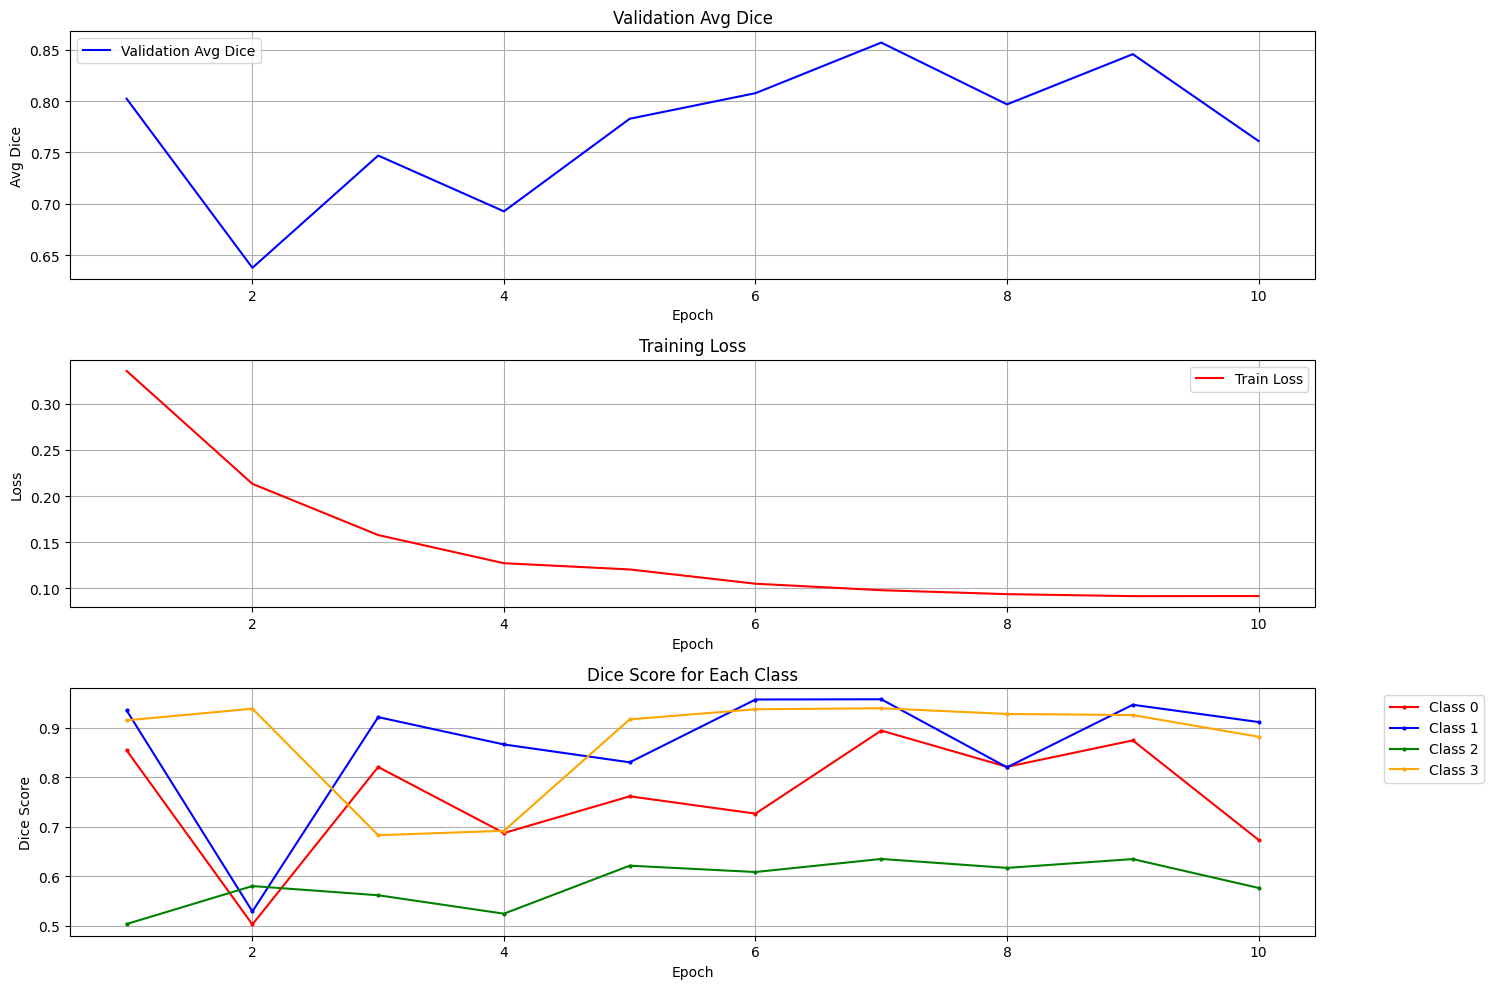

In [ ]:
num_epoches = 10
model, criterion, optimizer = init_model()
final_model = train(model, criterion, optimizer, train_loader, val_loader, epochs=num_epoches)

Модель без весов для каждого класса

In [ ]:
class SeverstalSteelLoss(nn.Module):
    def __init__(self, bce_weight=0.5, dice_weight=0.5, smooth=1e-6):
        super(SeverstalSteelLoss, self).__init__()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.smooth = smooth

        self.bce_loss = nn.BCEWithLogitsLoss()
        self.dice_loss = smp.losses.DiceLoss(mode='multilabel', smooth=smooth, from_logits=True)

    def forward(self, predictions, targets):
        bce_loss = self.bce_loss(predictions, targets)
        dice_loss = self.dice_loss(predictions, targets)

        total_loss = self.bce_weight * bce_loss + self.dice_weight * dice_loss

        return total_loss

def init_model():
    model = SegModel().to(device)
    criterion = SeverstalSteelLoss(bce_weight=0.5, dice_weight=0.5)
    optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
    return model, criterion, optimizer

Epoch 1/20
--------------------------------------------------
loss: 0.6887 | [    0/  667]
loss: 0.6028 | [   10/  667]
loss: 0.7004 | [   20/  667]
loss: 0.5632 | [   30/  667]
loss: 0.6801 | [   40/  667]
loss: 0.5323 | [   50/  667]
loss: 0.6304 | [   60/  667]
loss: 0.6184 | [   70/  667]
loss: 0.6043 | [   80/  667]
loss: 0.7308 | [   90/  667]
loss: 0.4566 | [  100/  667]
loss: 0.5950 | [  110/  667]
loss: 0.4403 | [  120/  667]
loss: 0.4079 | [  130/  667]
loss: 0.5514 | [  140/  667]
loss: 0.4131 | [  150/  667]
loss: 0.3984 | [  160/  667]
loss: 0.4105 | [  170/  667]
loss: 0.4092 | [  180/  667]
loss: 0.3936 | [  190/  667]
loss: 0.5114 | [  200/  667]
loss: 0.3717 | [  210/  667]
loss: 0.5041 | [  220/  667]
loss: 0.4746 | [  230/  667]
loss: 0.4584 | [  240/  667]
loss: 0.5911 | [  250/  667]
loss: 0.3333 | [  260/  667]
loss: 0.3401 | [  270/  667]
loss: 0.4798 | [  280/  667]
loss: 0.3295 | [  290/  667]
loss: 0.3392 | [  300/  667]
loss: 0.4315 | [  310/  667]
loss: 0.44

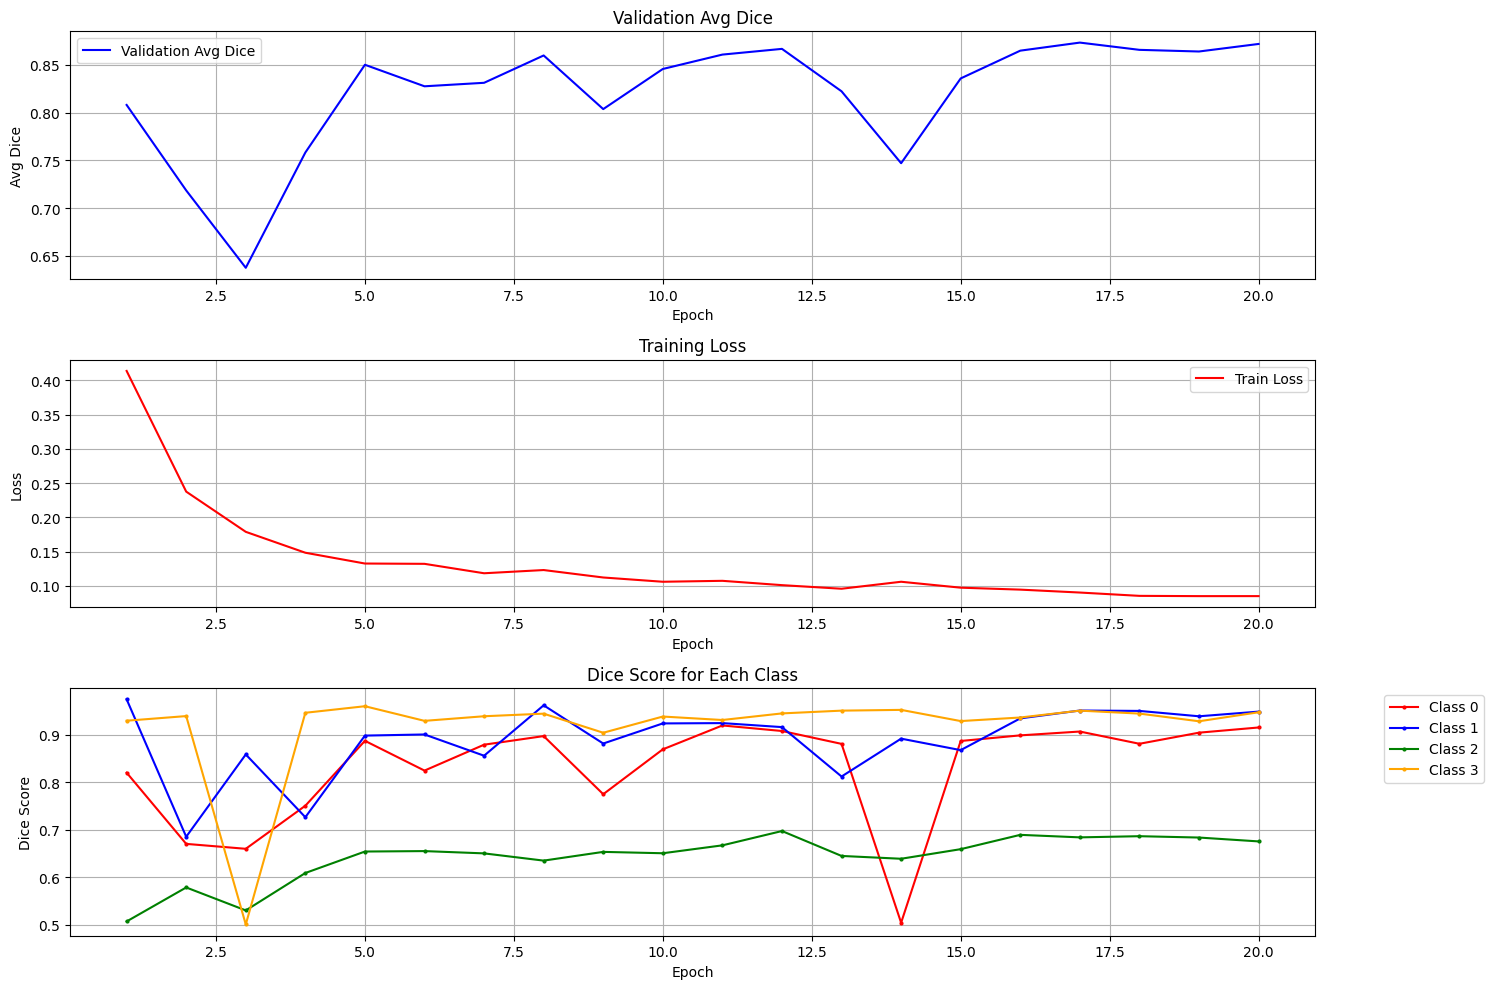

In [ ]:
train_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train.csv'
test_csv = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/sample_submission.csv'
train_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/train_images/'
test_folder = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/test_images/'
num_epoches = 20

train_loader, val_loader, test_loader = load_data(train_csv, test_csv, train_folder, test_folder)
model, criterion, optimizer = init_model()
final_model = train(model, criterion, optimizer, train_loader, val_loader, epochs=num_epoches)

In [ ]:
def masks_to_encoded_pixels(mask, target_class):
    binary_mask = np.where(mask.flatten(order='F') > 0.5, 1, 0)
    binary_mask = np.concatenate(([0], binary_mask, [0])) # добавляем по краям 0
    transition_indices = np.where(binary_mask[:-1] != binary_mask[1:])[0] + 1 # ищем индексы, где переход от 0 к 1 или от 1 к 0
    lengths = transition_indices[1::2] - transition_indices[::2] # индекс конца - индекс начала дефекта
    starts = transition_indices[::2]

    return ' '.join(f"{start} {length}" for start, length in zip(starts, lengths))

In [ ]:
train_df = pd.read_csv(train_csv)
model = SegModel().to(device)
model_path = '/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/model_epoch_8_1759003152.241805.pth'
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [ ]:
# предсказания на тестовом наборе данных

final_submission = []
model.eval()
with torch.no_grad():
    for filenames, images, _ in test_loader:
        images = images.to(device)
        preds = model(images)
        probs = torch.sigmoid(preds).cpu().numpy()

        for idx, file_name in enumerate(filenames):
            class_encoded_pixels = []

            for class_index in range(4):
                encoded_pix = masks_to_encoded_pixels(probs[idx, class_index], class_index)
                class_encoded_pixels.append((file_name, class_index + 1, encoded_pix))

            final_submission.extend(class_encoded_pixels)

submission_df = pd.DataFrame(final_submission, columns=['ImageId', 'EncodedPixels', 'ClassId'])
submission_df.to_csv('/content/drive/MyDrive/DL_HSE_2025_fall/homeworks/hw2/data/submission.csv', index=False)

Визуализация предсказаний модели для тренировочных данных

In [ ]:
# количество классов дефектов для каждого изображения
image_class_counts = train_df.groupby('ImageId')['ClassId'].nunique()

images_by_defect_count = {
    2: image_class_counts[image_class_counts == 2].index.tolist(),
    3: image_class_counts[image_class_counts == 3].index.tolist(),
    4: image_class_counts[image_class_counts == 4].index.tolist()
}

print(f"Количество изображений с 2 дефектами: {len(images_by_defect_count[2])}")
print(f"Количество изображений с 3 дефектами: {len(images_by_defect_count[3])}")
print(f"Количество изображений с 4 дефектами: {len(images_by_defect_count[4])}")

Количество изображений с 2 дефектами: 425
Количество изображений с 3 дефектами: 2
Количество изображений с 4 дефектами: 0


In [ ]:
# все маски дефектов на изображении с разными цветами
def show_all_masks(ax, image, all_masks, alpha=0.5, title="Изображение с дефектами"):
    colors = [
        (255, 0, 0),    # Красный для класса 1
        (0, 255, 0),    # Зеленый для класса 2
        (0, 0, 255),    # Синий для класса 3
        (255, 255, 0)   # Желтый для класса 4
    ]

    display_image = image.copy().astype(np.float32)

    for class_idx in range(all_masks.shape[2]):
        mask = all_masks[:, :, class_idx]
        color = colors[class_idx]

        for c in range(3):
            display_image[:, :, c] = np.where(
                mask == 1,
                display_image[:, :, c] * (1 - alpha) + color[c] * alpha,
                display_image[:, :, c])

    ax.imshow(display_image.astype(np.uint8))
    ax.set_title(title)
    ax.axis('off')

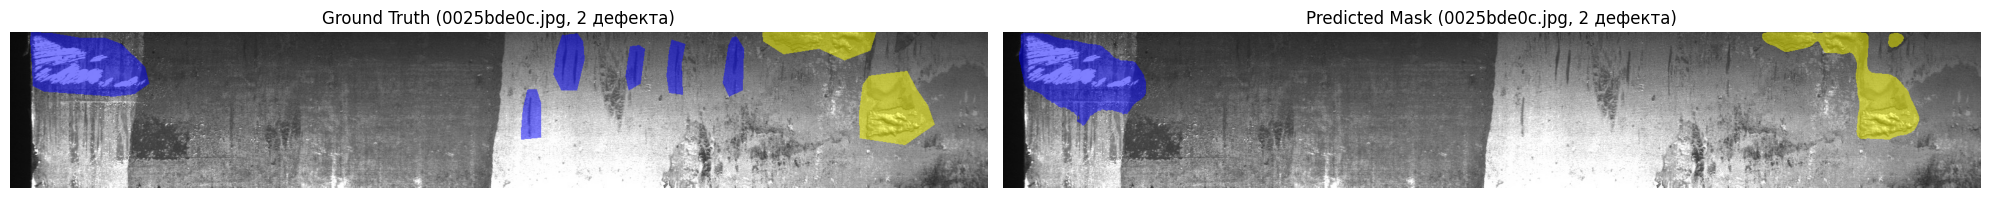

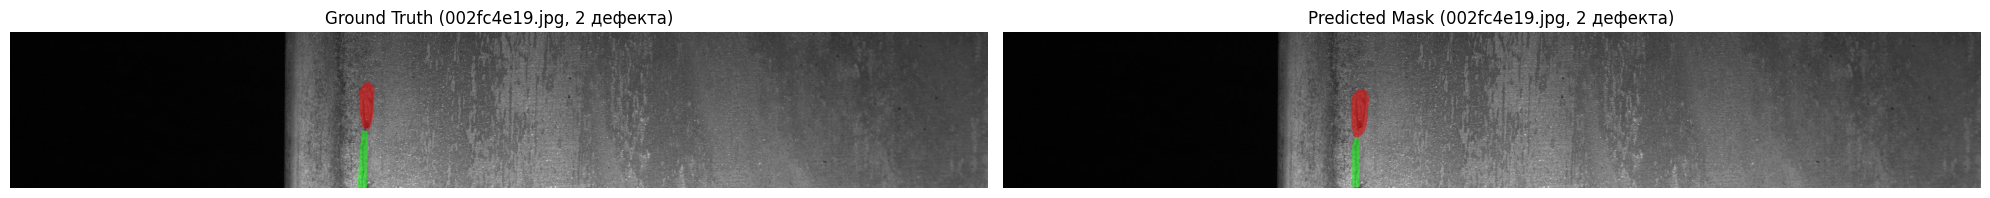

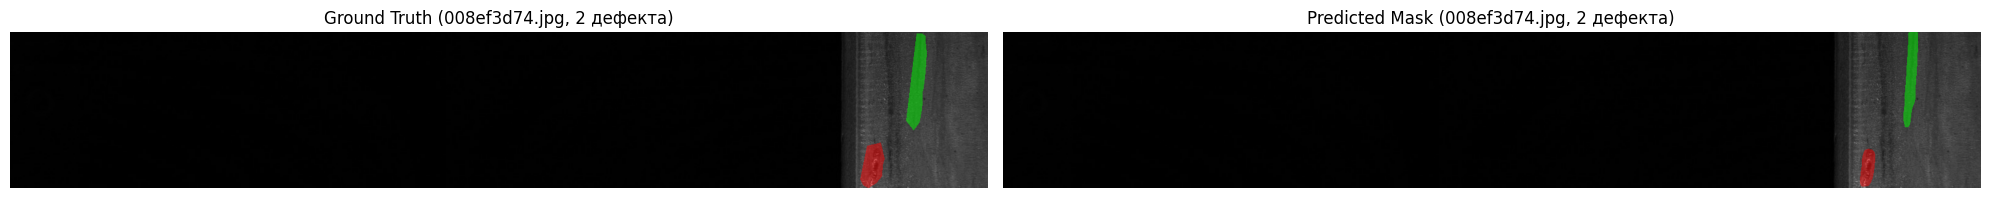

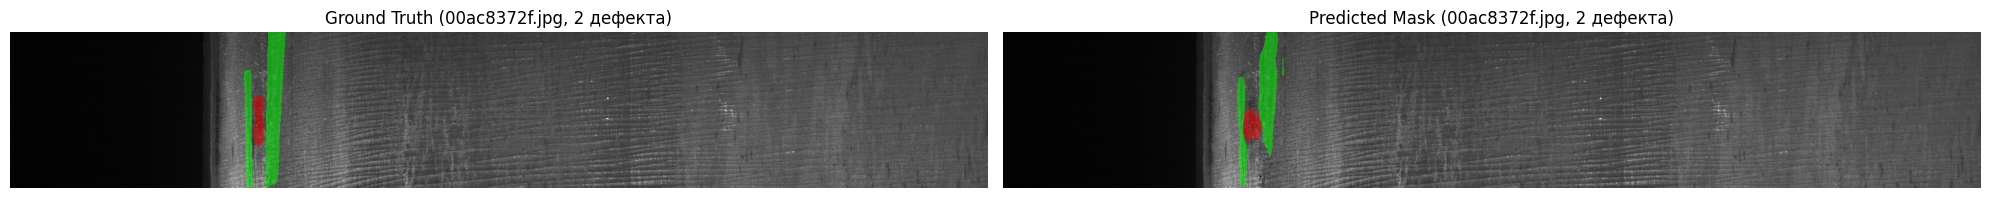

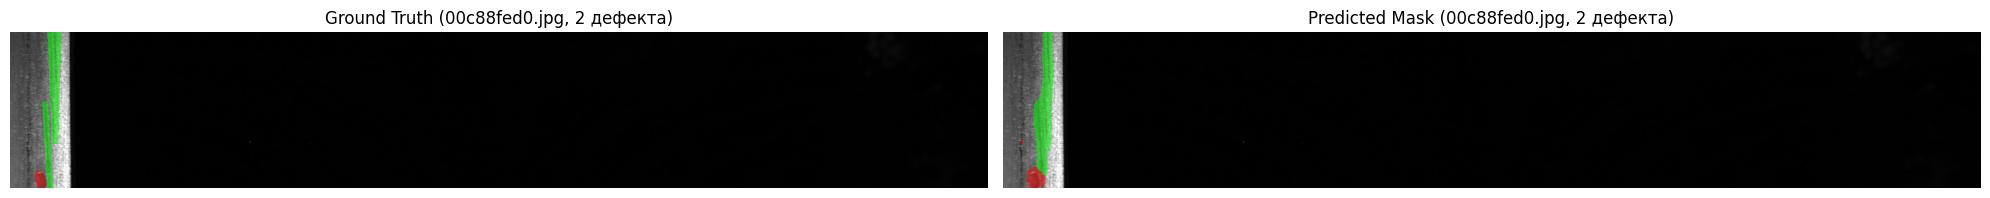

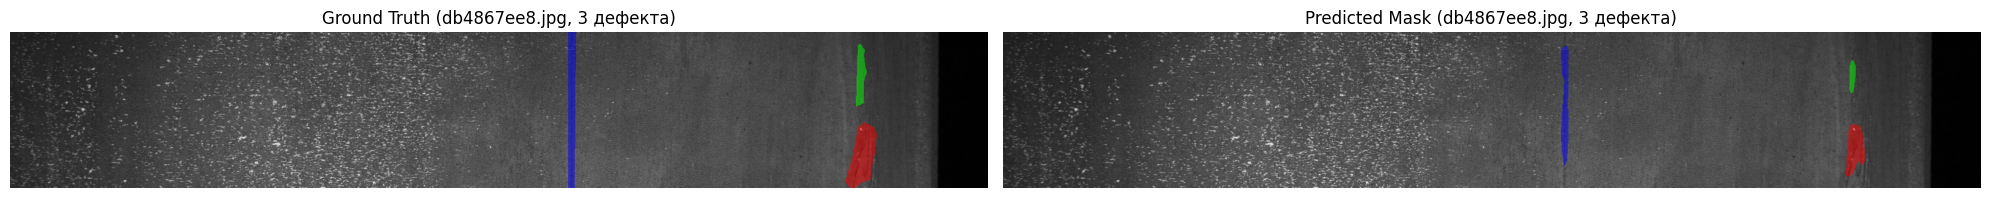

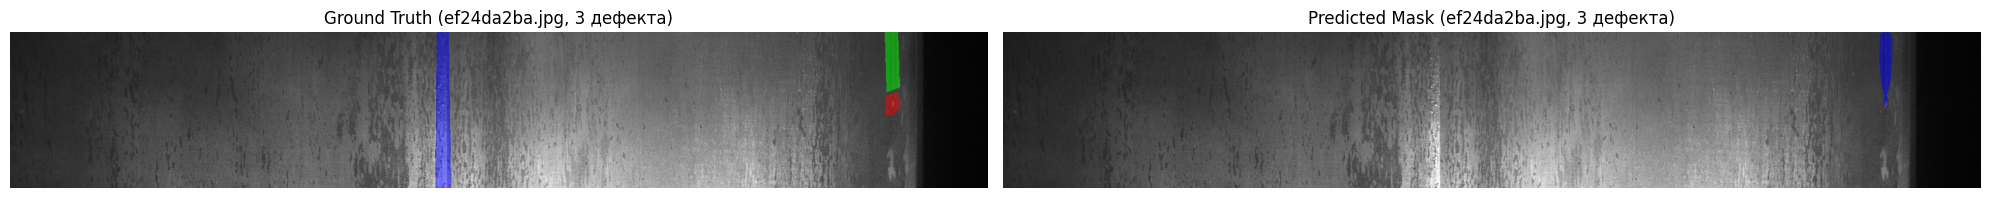

In [ ]:
model.eval()
for defect_count, image_list in images_by_defect_count.items():
    if not image_list:
        continue

    sample_images = image_list[:5]

    for img_id in sample_images:
        img_path = os.path.join(train_folder, img_id)
        img = np.array(Image.open(img_path).convert('RGB'))
        # unsqueeze, чтобы добавить размерность и передать в модель в виде батча из одного изображения (1, c, h, w)
        original_img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)
        ground_truth_masks = encoded_pixels_to_masks(img_id, train_df)

        with torch.no_grad():
            pred = model(original_img_tensor)
            pred_masks_tensor = (torch.sigmoid(pred) > 0.5).float()
            pred_masks_np = pred_masks_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy() # обратно в формат PIL

        fig, axes = plt.subplots(1, 2, figsize=(20, 10))

        show_all_masks(axes[0], img, ground_truth_masks, alpha=0.5,
                       title=f"Ground Truth ({img_id}, {defect_count} дефекта)")

        show_all_masks(axes[1], img, pred_masks_np, alpha=0.5,
                       title=f"Predicted Mask ({img_id}, {defect_count} дефекта)")

        plt.tight_layout()
        plt.show()

Визуализация предсказаний модели для тестовых данных

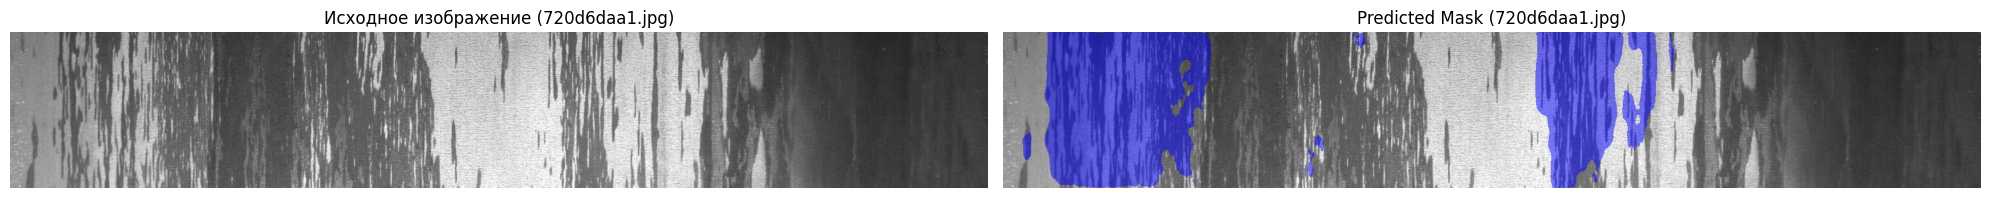

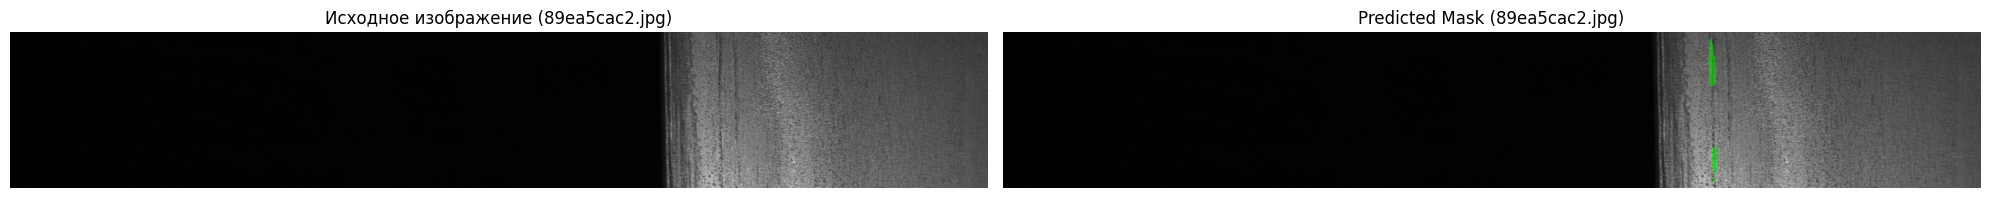

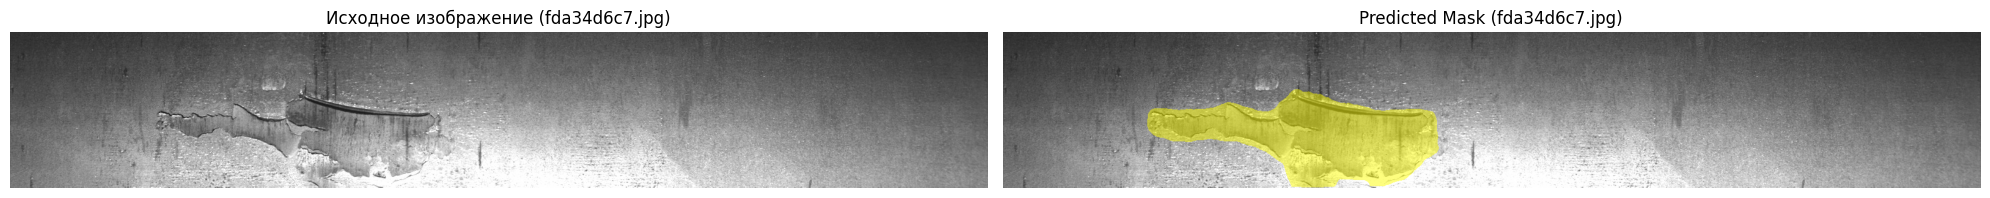

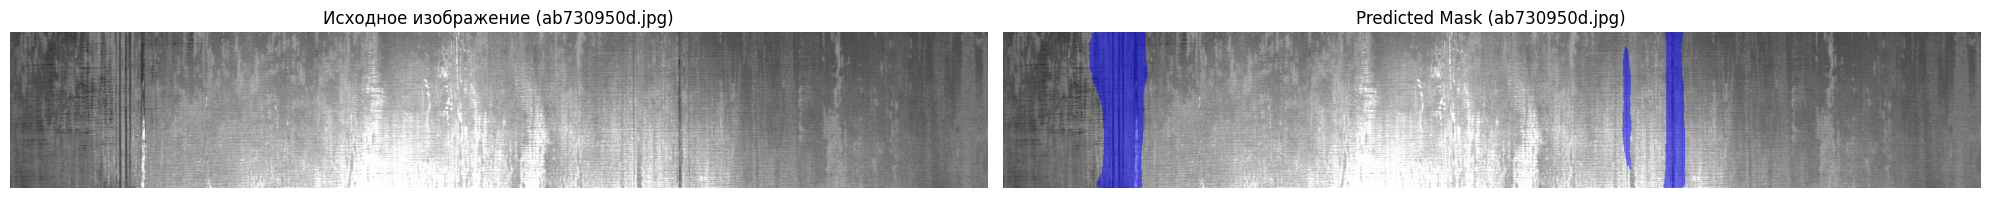

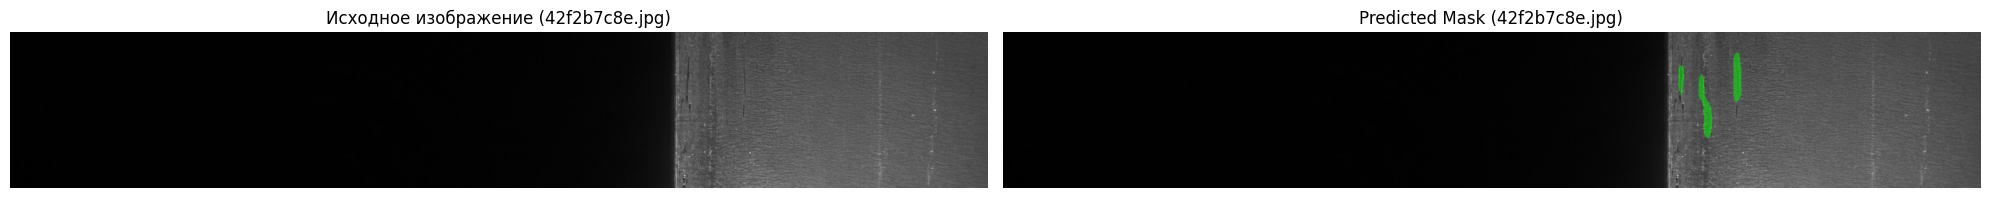

In [ ]:
import random
all_test_images = os.listdir(test_folder)
random_image_ids = random.sample(all_test_images, 5)

for img_id in random_image_ids:
    img_path = os.path.join(test_folder, img_id)
    img = np.array(Image.open(img_path).convert('RGB'))

    original_img_tensor = torch.tensor(img, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0).to(device)

    with torch.no_grad():
        pred = model(original_img_tensor)
        pred_masks_tensor = (torch.sigmoid(pred) > 0.5).float()
        pred_masks_np = pred_masks_tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(img)
    axes[0].set_title(f"Исходное изображение ({img_id})")
    axes[0].axis('off')

    show_all_masks(axes[1], img, pred_masks_np, alpha=0.5,
                   title=f"Predicted Mask ({img_id})")

    plt.tight_layout()
    plt.show()